In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the master dataset
df = pd.read_csv("../../data/census/acs_demographics.csv")

In [52]:
# 2. Calculate Demographic Percentages
# Using Total Population (B01003_001E) as the denominator
df['pct_white'] = (df['B03002_003E'] / df['B01003_001E']) * 100
df['pct_black'] = (df['B03002_004E'] / df['B01003_001E']) * 100
df['pct_asian'] = (df['B03002_006E'] / df['B01003_001E']) * 100
df['pct_hispanic'] = (df['B03002_012E'] / df['B01003_001E']) * 100

# 3. Calculate Infrastructure & Socioeconomic Percentages
# Transit: Public transit commuters (B08301_010E) / Total Workers 16+ (B08301_001E)
df['pct_transit_commuters'] = (df['B08301_010E'] / df['B08301_001E']) * 100

# Broadband: Broadband households (B28002_004E) / Total Households (B28002_001E)
df['pct_broadband_access'] = (df['B28002_004E'] / df['B28002_001E']) * 100

# Rent Burden: Severely rent-burdened (B25070_010E) / Total Renter Households (B25070_001E)
df['pct_severe_rent_burden'] = (df['B25070_010E'] / df['B25070_001E']) * 100

# Create a total count of all households paying 30% or more
df['rent_burdened_count'] = (
    df['B25070_007E'] + 
    df['B25070_008E'] + 
    df['B25070_009E'] + 
    df['B25070_010E']
)

# Standard Rent Burden: 30% or more / Total Renter Households (B25070_001E)
df['pct_rent_burden'] = (df['rent_burdened_count'] / df['B25070_001E']) * 100

# 4. Rename the remaining raw columns for readability
df.rename(columns={
    'B19013_001E': 'median_income',
    'B01003_001E': 'total_population'
}, inplace=True)

# 5. Filter the dataframe to only the columns we care about and round to 2 decimals
analysis_cols = [
    'city_name', 'total_population', 'median_income', 
    'pct_white', 'pct_black', 'pct_asian', 'pct_hispanic',
    'pct_transit_commuters', 'pct_broadband_access', 'pct_severe_rent_burden', 'pct_rent_burden'
]
analysis_df = df[analysis_cols].round(2)

# Save this cleaned data for the NLP portion
analysis_df.to_csv("cleaned_demographic_metrics.csv", index=False)

# 6. Print a comparison against the County Baseline
print("--- DEMOGRAPHIC ANALYSIS SUMMARY ---")
print(analysis_df[['city_name', 'total_population', 'median_income', 'pct_white', 'pct_black', 'pct_asian', 'pct_hispanic', 'pct_severe_rent_burden', 'pct_transit_commuters', 'pct_broadband_access',]].to_string(index=False))

print("\n--- BASELINE COMPARISON ---")
# Extract the county baseline row
county_baseline = analysis_df[analysis_df['city_name'] == 'Orange County (Baseline)'].iloc[0]

# Calculate how each city deviates from the county average for Rent Burden
for index, row in analysis_df.iterrows():
    if row['city_name'] != 'Orange County (Baseline)':
        diff = row['pct_severe_rent_burden'] - county_baseline['pct_severe_rent_burden']
        direction = "higher" if diff > 0 else "lower"
        print(f"{row['city_name']}: Severe rent burden is {abs(diff):.1f}% {direction} than the county average.")

--- DEMOGRAPHIC ANALYSIS SUMMARY ---
               city_name  total_population  median_income  pct_white  pct_black  pct_asian  pct_hispanic  pct_severe_rent_burden  pct_transit_commuters  pct_broadband_access
Orange County (Baseline)            145919          85785      68.50      10.64       7.79          8.73                   30.11                   4.73                 92.44
             Chapel Hill             58919          85940      64.65      10.32      13.38          6.77                   36.99                   7.03                 92.45
                Carrboro             21242          76933      65.10      12.87       9.05          8.06                   24.31                   9.38                 96.05
            Hillsborough              9534          86250      73.81      12.43       2.34          7.99                   22.39                   1.55                 94.06
                  Mebane             17899          78419      57.12      24.41       4.42   

## Demographic Heatmap

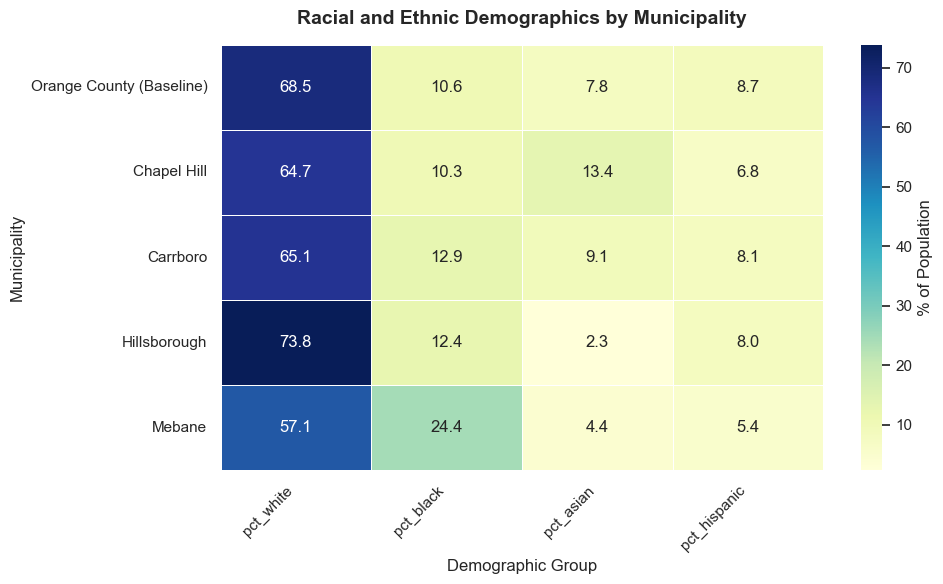

In [53]:


# Set the style
sns.set_theme(style="whitegrid")

# Isolate the demographic columns and set the city name as the index
demographic_cols = ['pct_white', 'pct_black', 'pct_asian', 'pct_hispanic']
demo_df = analysis_df.set_index('city_name')[demographic_cols]

# Generate the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    demo_df, 
    annot=True, 
    cmap='YlGnBu', 
    fmt='.1f', 
    linewidths=0.5,
    cbar_kws={'label': '% of Population'}
)

plt.title('Racial and Ethnic Demographics by Municipality', fontsize=14, pad=15, weight='bold')
plt.xlabel('Demographic Group', fontsize=12)
plt.ylabel('Municipality', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig("../../data/census/demographic_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

## Rent Burden (30% or more of income) Comparison

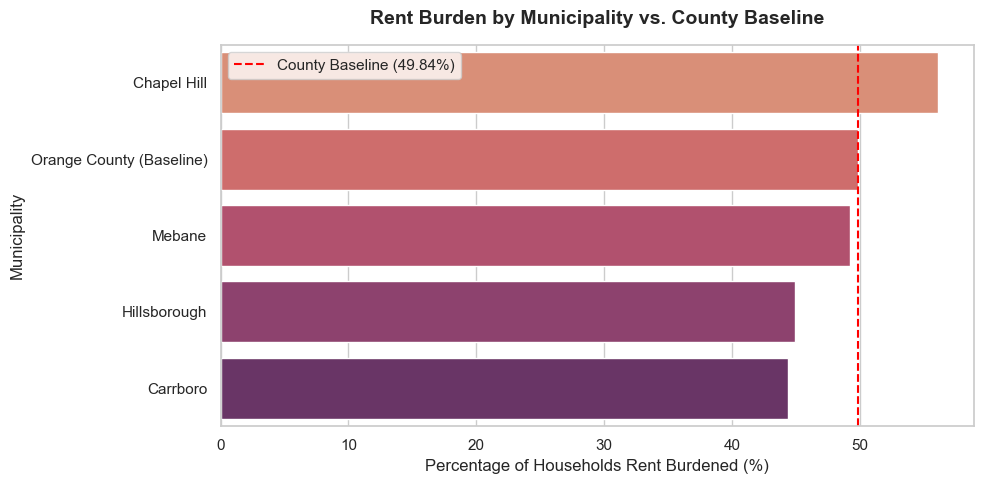

In [58]:
plt.figure(figsize=(10, 5))

# Generate horizontal bar plot for severe rent burden
sns.barplot(
    x='pct_rent_burden', 
    y='city_name', 
    data=analysis_df.sort_values('pct_rent_burden', ascending=False), 
    palette='flare',
    hue='city_name',
    legend=False
)

# Titles and labels
plt.title('Rent Burden by Municipality vs. County Baseline', fontsize=14, pad=15, weight='bold')
plt.xlabel('Percentage of Households Rent Burdened (%)', fontsize=12)
plt.ylabel('Municipality', fontsize=12)

# Add a vertical line to represent the Orange County Baseline
baseline_value = analysis_df.loc[analysis_df['city_name'] == 'Orange County (Baseline)', 'pct_rent_burden'].values[0]
plt.axvline(x=baseline_value, color='red', linestyle='--', label=f'County Baseline ({baseline_value}%)')
plt.legend()

plt.tight_layout()
plt.savefig("../../data/census/rent_burden_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

## Severe Rent Burden (50% or more of Income) Comparison

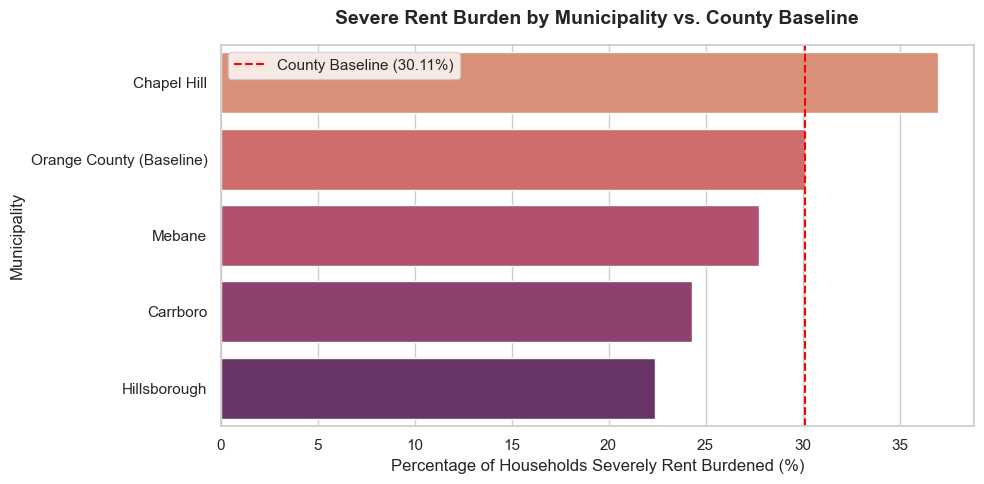

In [55]:
plt.figure(figsize=(10, 5))

# Generate horizontal bar plot for severe rent burden
sns.barplot(
    x='pct_severe_rent_burden', 
    y='city_name', 
    data=analysis_df.sort_values('pct_severe_rent_burden', ascending=False), 
    palette='flare',
    hue='city_name',
    legend=False
)

# Titles and labels
plt.title('Severe Rent Burden by Municipality vs. County Baseline', fontsize=14, pad=15, weight='bold')
plt.xlabel('Percentage of Households Severely Rent Burdened (%)', fontsize=12)
plt.ylabel('Municipality', fontsize=12)

# Add a vertical line to represent the Orange County Baseline
baseline_value = analysis_df.loc[analysis_df['city_name'] == 'Orange County (Baseline)', 'pct_severe_rent_burden'].values[0]
plt.axvline(x=baseline_value, color='red', linestyle='--', label=f'County Baseline ({baseline_value}%)')
plt.legend()

plt.tight_layout()
plt.savefig("../../data/census/severe_rent_burden_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

## Transit Commuters

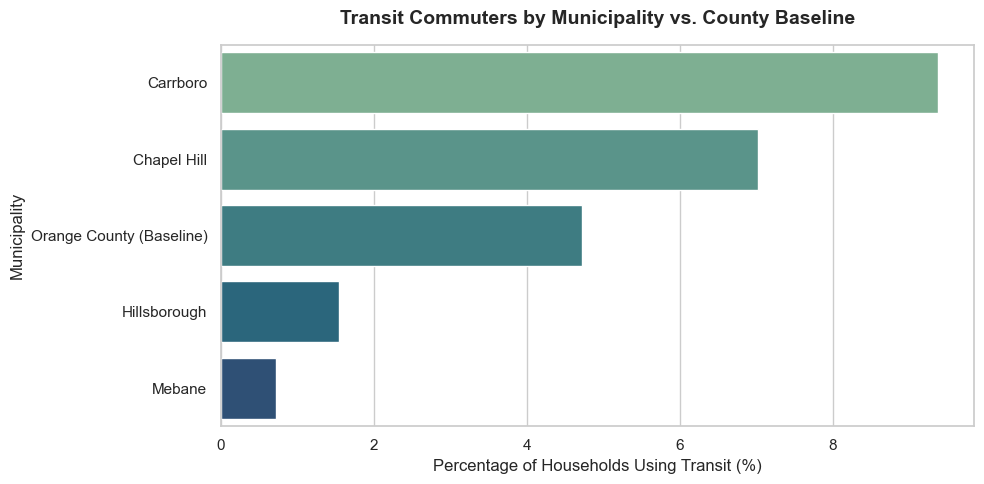

In [56]:
plt.figure(figsize=(10, 5))

# Generate horizontal bar plot for severe rent burden
sns.barplot(
    x='pct_transit_commuters', 
    y='city_name', 
    data=analysis_df.sort_values('pct_transit_commuters', ascending=False), 
    palette='crest',
    hue='city_name',
    legend=False
)

# Titles and labels
plt.title('Transit Commuters by Municipality vs. County Baseline', fontsize=14, pad=15, weight='bold')
plt.xlabel('Percentage of Households Using Transit (%)', fontsize=12)
plt.ylabel('Municipality', fontsize=12)

plt.tight_layout()
plt.savefig("../../data/census/transit_commuters_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

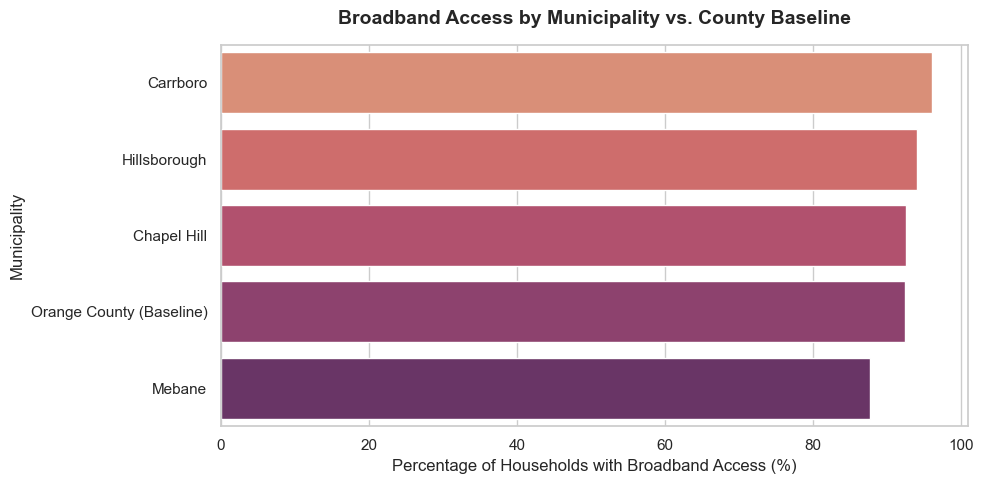

In [57]:
plt.figure(figsize=(10, 5))

# Generate horizontal bar plot for severe rent burden
sns.barplot(
    x='pct_broadband_access', 
    y='city_name', 
    data=analysis_df.sort_values('pct_broadband_access', ascending=False), 
    palette='flare',
    hue='city_name',
    legend=False
)

# Titles and labels
plt.title('Broadband Access by Municipality vs. County Baseline', fontsize=14, pad=15, weight='bold')
plt.xlabel('Percentage of Households with Broadband Access (%)', fontsize=12)
plt.ylabel('Municipality', fontsize=12)

plt.tight_layout()
plt.savefig("../../data/census/broadband_access_comparison.png", dpi=300, bbox_inches='tight')
plt.show()